In [10]:
# Standard Libraries
import os
import json
import gc
import re

# Data Manipulation & Analysis
import numpy as np
import pandas as pd
from scipy.special import rel_entr

# Data Visualization
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

# PyTorch & PyTorch Geometric
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.nn import Linear
from torch.autograd import Function
from torch_geometric.nn import SGConv, SAGEConv
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

# Sklearn Utilities
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve, auc, f1_score

# Graph Utilities
import networkx as nx

# Set the device to CUDA if available, otherwise fallback to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [6]:
cc = pd.read_csv('./ieee-data/train_transaction.csv') 
print("Transactions:", cc.shape[0])
print("Features:", cc.shape[1])

Transactions: 590540
Features: 394


In [8]:
cc.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
cc.describe()

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,524834.000000,...,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.00000,82351.000000,82351.000000,82351.000000,82351.000000
mean,3.282270e+06,0.034990,7.372311e+06,135.027176,9898.734658,362.555488,153.194925,199.278897,290.733794,86.800630,...,0.775874,721.741883,1375.783644,1014.622782,9.807015,59.16455,28.530903,55.352422,151.160542,100.700882
std,1.704744e+05,0.183755,4.617224e+06,239.162522,4901.170153,157.793246,11.336444,41.244453,101.741072,2.690623,...,4.727971,6217.223583,11169.275702,7955.735482,243.861391,387.62948,274.576920,668.486833,1095.034387,814.946722
min,2.987000e+06,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000,100.000000,100.000000,10.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,3.134635e+06,0.000000,3.027058e+06,43.321000,6019.000000,214.000000,150.000000,166.000000,204.000000,87.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,3.282270e+06,0.000000,7.306528e+06,68.769000,9678.000000,361.000000,150.000000,226.000000,299.000000,87.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
75%,3.429904e+06,0.000000,1.124662e+07,125.000000,14184.000000,512.000000,150.000000,226.000000,330.000000,87.000000,...,0.000000,0.000000,25.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
max,3.577539e+06,1.000000,1.581113e+07,31937.391000,18396.000000,600.000000,231.000000,237.000000,540.000000,102.000000,...,55.000000,160000.000000,160000.000000,160000.000000,55125.000000,55125.00000,55125.000000,104060.000000,104060.000000,104060.000000


In [7]:
idt = pd.read_csv('./ieee-data/train_identity.csv') 
print("Identity:", idt.shape[0])
print("Features:", idt.shape[1])

Identity: 144233
Features: 41


In [9]:
idt.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [12]:
idt.describe()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,1.442330e+05,144233.000000,140872.000000,66324.000000,66324.000000,136865.000000,136865.000000,5155.000000,5155.000000,74926.000000,...,139369.000000,45113.000000,139318.000000,139261.000000,5159.000000,5169.000000,4747.000000,5132.000000,5163.000000,77586.000000
mean,3.236329e+06,-10.170502,174716.584708,0.060189,-0.058938,1.615585,-6.698710,13.285354,-38.600388,0.091023,...,189.451377,14.237337,353.128174,403.882666,368.269820,16.002708,12.800927,329.608924,149.070308,26.508597
std,1.788496e+05,14.347949,159651.816856,0.598231,0.701015,5.249856,16.491104,11.384207,26.084899,0.983842,...,30.375360,1.561302,141.095343,152.160327,198.847038,6.897665,2.372447,97.461089,32.101995,3.737502
min,2.987004e+06,-100.000000,1.000000,-13.000000,-28.000000,-72.000000,-100.000000,-46.000000,-100.000000,-36.000000,...,100.000000,10.000000,100.000000,100.000000,100.000000,10.000000,11.000000,100.000000,100.000000,0.000000
25%,3.077142e+06,-10.000000,67992.000000,0.000000,0.000000,0.000000,-6.000000,5.000000,-48.000000,0.000000,...,166.000000,13.000000,266.000000,256.000000,252.000000,14.000000,11.000000,321.000000,119.000000,24.000000
50%,3.198818e+06,-5.000000,125800.500000,0.000000,0.000000,0.000000,0.000000,14.000000,-34.000000,0.000000,...,166.000000,15.000000,341.000000,472.000000,252.000000,14.000000,11.000000,321.000000,149.000000,24.000000
75%,3.392923e+06,-5.000000,228749.000000,0.000000,0.000000,1.000000,0.000000,22.000000,-23.000000,0.000000,...,225.000000,15.000000,427.000000,533.000000,486.500000,14.000000,15.000000,371.000000,169.000000,32.000000
max,3.577534e+06,0.000000,999595.000000,10.000000,0.000000,52.000000,0.000000,61.000000,0.000000,25.000000,...,229.000000,29.000000,671.000000,661.000000,854.000000,44.000000,26.000000,548.000000,216.000000,32.000000


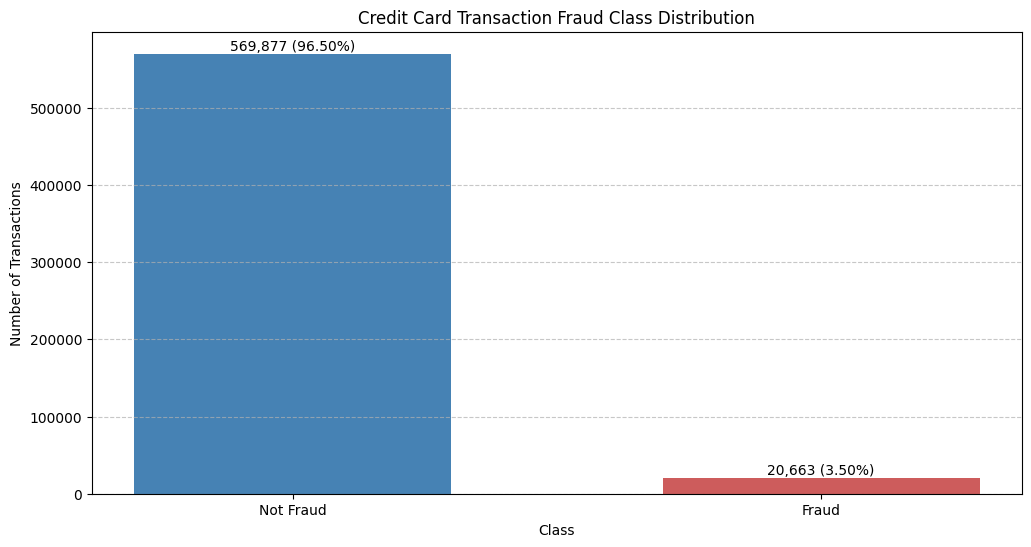

In [13]:
temp = cc["isFraud"].value_counts()
df = pd.DataFrame({'Class': temp.index, 'values': temp.values})

total = temp.sum()
df['percent'] = df['values'] / total * 100

plt.figure(figsize=(12, 6))
bars = plt.bar(df['Class'], df['values'], color=['steelblue', 'indianred'], width=0.6)
for bar, value, percent in zip(bars, df['values'], df['percent']):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{value:,} ({percent:.2f}%)', ha='center', va='bottom')
plt.title('Credit Card Transaction Fraud Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')
plt.xticks(df['Class'], ['Not Fraud', 'Fraud'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
c0 = cc.loc[cc['isFraud'] == 0]
c1 = cc.loc[cc['isFraud'] == 1]

kl_divergences = {}

for feature in cc.columns[55:394]:

    # bỏ feature nếu phương sai = 0
    if c0[feature].var() == 0 or c1[feature].var() == 0:
        continue

    min_val = min(c0[feature].min(), c1[feature].min())
    max_val = max(c0[feature].max(), c1[feature].max())

    # tránh trường hợp min = max
    if min_val == max_val:
        continue

    range_bins = np.linspace(min_val, max_val, 100)

    p, _ = np.histogram(c0[feature], bins=range_bins, density=True)
    q, _ = np.histogram(c1[feature], bins=range_bins, density=True)

    epsilon = 1e-10
    p = p + epsilon
    q = q + epsilon

    kl_pq = np.sum(rel_entr(p, q))
    kl_qp = np.sum(rel_entr(q, p))
    kl = 0.5 * (kl_pq + kl_qp)

    kl_divergences[feature] = kl

In [18]:
# sort giảm dần theo KL
sorted_kl_divergences = sorted(
    kl_divergences.items(),
    key=lambda item: item[1],
    reverse=True
)

top_n = 20
for feature, kl_value in sorted_kl_divergences[:top_n]:
    print(f"{feature}: {kl_value:.6f}")

V94: 17.166009
V49: 7.000685
V51: 6.900810
V48: 6.870468
V50: 6.595958
V90: 6.328450
V29: 5.982160
V69: 5.901474
V21: 5.422685
V91: 5.303305
V70: 4.970482
V79: 4.924600
V10: 4.848665
V149: 4.786570
V33: 4.565040
V93: 4.541444
V57: 4.467691
V92: 4.368593
V15: 4.249797
V43: 4.211125


KL càng lớn → phân phối của feature giữa fraud và non-fraud càng khác nhau. 

KL gần 0 → hai phân phối gần giống nhau → feature đó ít khả năng phân biệt.

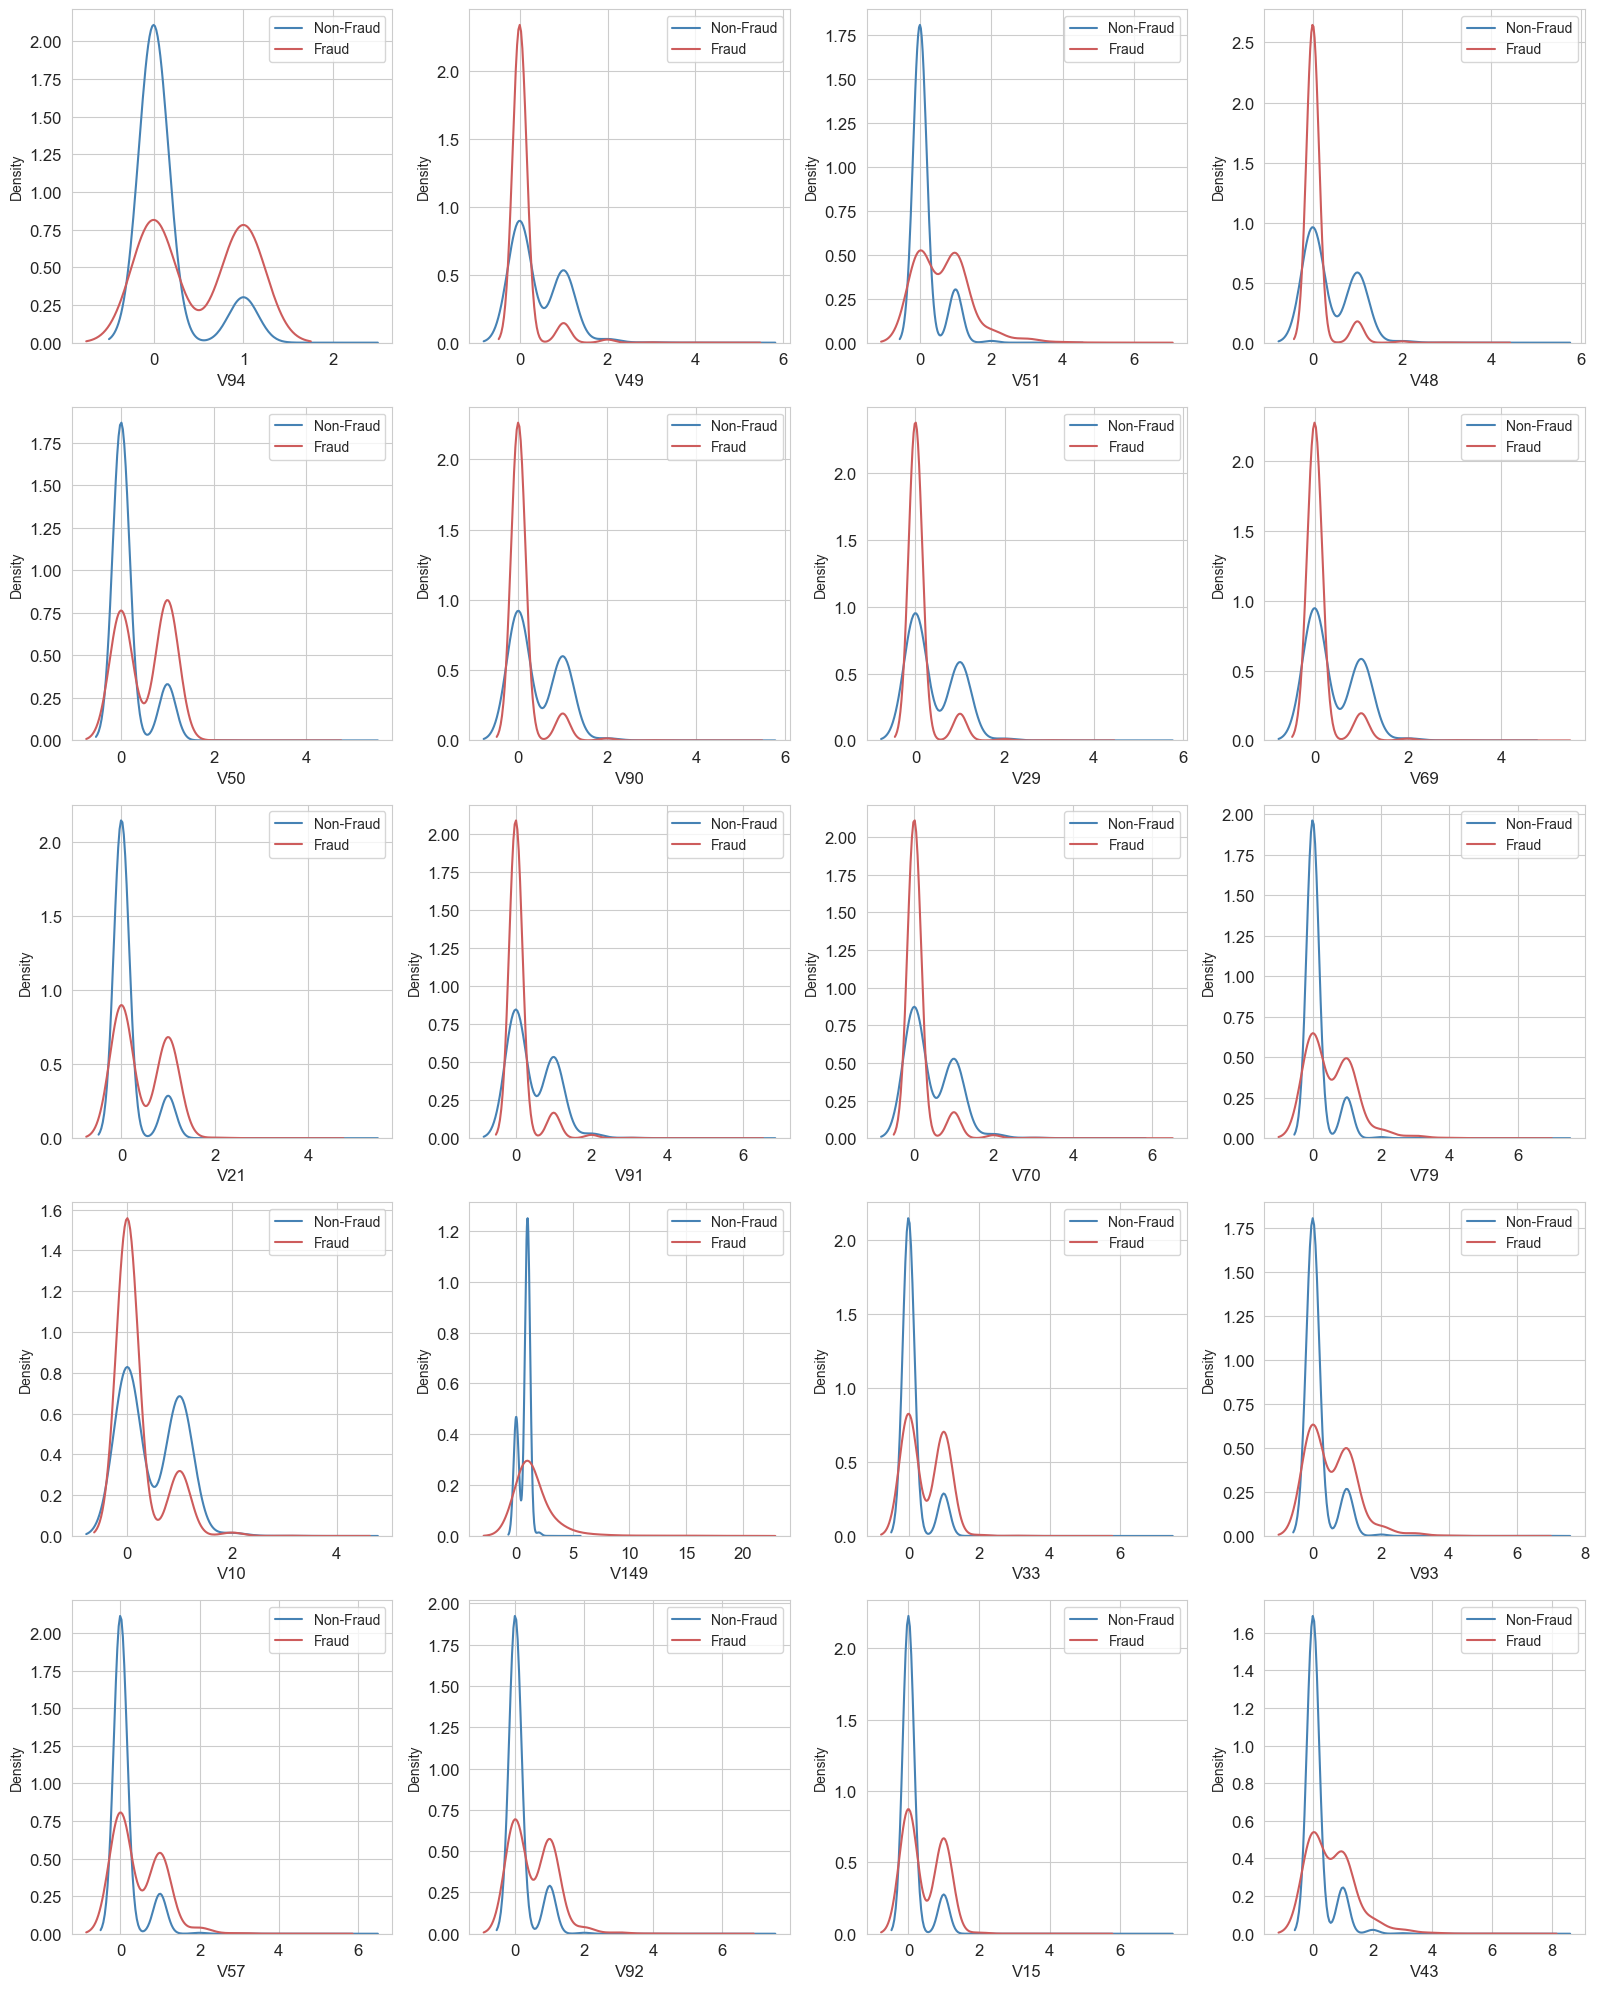

In [21]:
top_features = [item[0] for item in sorted_kl_divergences[:top_n]]

sns.set_style('whitegrid')
fig, ax = plt.subplots(5, 4, figsize=(16, 20))
fig.subplots_adjust(hspace=0.5)

for i, feature in enumerate(top_features, 1):
    plt.subplot(5, 4, i)

    sns.kdeplot(c0[feature], bw_method=0.5, label="Non-Fraud", color='steelblue')
    sns.kdeplot(c1[feature], bw_method=0.5, label="Fraud", color='indianred')

    plt.xlabel(feature, fontsize=12)
    plt.legend()
    plt.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.show()